# Example 12 (JAX): Batched Equilibrium Solving via GPU Vectorization

This notebook demonstrates the **batched equilibrium solving** capabilities of FreeGSNKE using JAX vectorization (`jax.vmap`) and GPU acceleration (NVIDIA CUDA / Tensor Cores).

### Key Features Demonstrated:
1. **Drop-in GPU Vectorization**: Simultaneously solving an ensemble of equilibria across coil current scans or parameter sweeps.
2. **Fused PDE Inversion**: Inverting the 4th-order Grad-Shafranov elliptic PDE and Green's boundary convolution for all equilibria in parallel in a single cuBLAS GEMM call.
3. **Exact Numerical Accuracy**: Validating that batched solutions accurately match standard single-solve equilibria.
4. **High-Throughput Scaling**: Benchmarking throughput (solves/sec) across batch sizes $B \in [1, 8, 16, 32, 64]$.
5. **Ensemble Visualization**: Plotting 2D poloidal flux surfaces and separatrices across the batch.


In [1]:
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp
from freegsnke import (
    GSstaticsolver,
    build_machine,
    equilibrium_update,
    get_backend,
    set_backend,
)
from freegsnke.jax import BatchedEquilibriumSolver, get_jax_devices, is_jax_available
from freegsnke.jtor_update import ConstrainPaxisIp

print(f"JAX Available: {is_jax_available()}")
print(f"Active Devices: {get_jax_devices()}")
set_backend("jax")
print(f"FreeGSNKE Backend: {get_backend()}")


JAX Available: True


Active Devices: [CudaDevice(id=0)]
FreeGSNKE Backend: jax


## 1. Machine & Equilibrium Setup
We load the MAST-U tokamak configuration and establish a baseline diverted equilibrium.


In [2]:
REPO_ROOT = Path(".").resolve() if (Path(".").resolve() / "machine_configs").exists() else Path("..").resolve()
MACHINE_CONFIG_DIR = REPO_ROOT / "machine_configs" / "test"
STATIC_CURRENT_BASELINE = REPO_ROOT / "freegsnke" / "tests" / "baselines" / "test_controlCurrents.npy"

tokamak = build_machine.tokamak(
    active_coils_path=str(MACHINE_CONFIG_DIR / "active_coils.pickle"),
    passive_coils_path=str(MACHINE_CONFIG_DIR / "passive_coils.pickle"),
    limiter_path=str(MACHINE_CONFIG_DIR / "limiter.pickle"),
    wall_path=str(MACHINE_CONFIG_DIR / "wall.pickle"),
    magnetic_probe_path=str(MACHINE_CONFIG_DIR / "magnetic_probes.pickle"),
)

eq = equilibrium_update.Equilibrium(
    tokamak=tokamak,
    Rmin=0.1, Rmax=2.0, Zmin=-2.2, Zmax=2.2,
    nx=65, ny=129,
)

# Fix non-controlled coils
eq.tokamak.set_coil_current("P6", 0)
eq.tokamak["P6"].control = False
eq.tokamak["Solenoid"].control = False
eq.tokamak.set_coil_current("Solenoid", 15000)

base_currents = np.load(STATIC_CURRENT_BASELINE)
eq.tokamak.setControlCurrents(base_currents)
eq.tokamak_psi = eq.tokamak.getPsitokamak(vgreen=eq._vgreen)

# Solve baseline equilibrium once to obtain a realistic initial state
profiles_ref = ConstrainPaxisIp(eq, 8.1e3, 6.2e5, 0.5, alpha_m=1.8, alpha_n=1.2)
solver_single = GSstaticsolver.NKGSsolver(eq, backend="jax")
solver_single.forward_solve(eq, profiles_ref, 1e-5)

base_plasma_psi = eq.plasma_psi.copy()
base_full_currents = eq.tokamak.current_vec.copy()
print(f"Baseline equilibrium solved: Ip = {eq._current/1e3:.1f} kA, psi_axis = {eq.psi_axis:.4f}")


Active coils --> built from pickle file.
Passive structures --> built from pickle file.
Limiter --> built from pickle file.
Wall --> built from pickle file.


Magnetic probes --> built from pickle file.


Resistance (R) and inductance (M) matrices --> built using actives (and passives if present).
Tokamak built.


Forward static solve SUCCESS. Tolerance 3.60e-06 (vs. requested 1.00e-05) reached in 16/100 iterations.
Baseline equilibrium solved: Ip = 620.0 kA, psi_axis = 0.1252


## 2. Generating a Batch of Coil Current Variations
We construct an ensemble of $B=8$ equilibria by scanning the current in the shaping/divertor coil system across a range of $\pm 600$ A.
In traditional CPU workflows, each equilibrium must be solved sequentially in Python. With the JAX GPU backend, the entire batch is evaluated in parallel.


In [3]:
B = 8
batch_currents = np.zeros((B, len(base_full_currents)))
delta_I = np.linspace(-600.0, 600.0, B)

for b in range(B):
    batch_currents[b] = base_full_currents.copy()
    # Vary upper shaping coil current
    batch_currents[b, 0] += delta_I[b]

print(f"Prepared batch of {B} equilibria with shaping coil variations: {delta_I} A")


Prepared batch of 8 equilibria with shaping coil variations: [-600.         -428.57142857 -257.14285714  -85.71428571   85.71428571
  257.14285714  428.57142857  600.        ] A


## 3. Simultaneous Batched Solve on GPU
We now solve all $B=8$ equilibria simultaneously using `BatchedEquilibriumSolver`.
The linear Grad-Shafranov PDE and boundary Green's convolutions for all 8 states are executed in parallel on GPU tensor cores.


In [4]:
batch_solver = BatchedEquilibriumSolver(eq)

t0 = time.perf_counter()
eq_list, prof_list, info = batch_solver.solve_batch(
    batch_currents=batch_currents,
    paxis=8.1e3,
    Ip=6.2e5,
    vacuum_ratio=0.5,
    alpha_m=1.8,
    alpha_n=1.2,
    target_relative_tolerance=1e-4,
    max_iterations=40,
    relaxation=0.5,
    initial_plasma_psi=base_plasma_psi,
    verbose=True,
)
t_batched = time.perf_counter() - t0

print(f"\nBatched solve complete in {t_batched:.3f} s ({t_batched/B*1000:.1f} ms per equilibrium)!")


--- Batched GS Solve for B=8 equilibria on GPU ---


  Iteration  0: max relative error = 2.135e-03 (mean = 1.215e-03)
  Iteration  5: max relative error = 1.269e-03 (mean = 7.211e-04)


  Iteration 10: max relative error = 8.101e-04 (mean = 4.587e-04)
  Iteration 15: max relative error = 5.157e-04 (mean = 2.915e-04)


  Iteration 20: max relative error = 3.278e-04 (mean = 1.849e-04)
  Iteration 25: max relative error = 2.081e-04 (mean = 1.171e-04)


  Iteration 30: max relative error = 1.321e-04 (mean = 7.435e-05)
  Iteration 34: max relative error = 9.175e-05 (mean = 5.169e-05)
--- Batched solve CONVERGED in 35 iterations: 1.746 s (218.2 ms/eq) ---



Batched solve complete in 1.838 s (229.8 ms per equilibrium)!


## 4. Verification of Accuracy vs Single Solves
We independently solve selected members of the ensemble using the standard `NKGSsolver.forward_solve` to verify that the batched solver maintains exact numerical accuracy.


In [5]:
test_indices = [0, B // 2, B - 1]
print("Validating batched results against independent single forward solves:")

for idx in test_indices:
    eq_single = eq.create_auxiliary_equilibrium()
    eq_single.tokamak.current_vec = batch_currents[idx].copy()
    eq_single.tokamak_psi = eq_list[idx].tokamak_psi.copy()
    eq_single.plasma_psi = base_plasma_psi.copy()
    
    prof_single = ConstrainPaxisIp(eq_single, 8.1e3, 6.2e5, 0.5, alpha_m=1.8, alpha_n=1.2)
    solver_single.forward_solve(eq_single, prof_single, 1e-5)
    
    psi_range = np.max(eq_single.plasma_psi) - np.min(eq_single.plasma_psi)
    max_diff = np.max(np.abs(eq_single.plasma_psi - eq_list[idx].plasma_psi))
    rel_error = max_diff / psi_range
    
    print(f"  Index {idx} (Delta I = {delta_I[idx]:+6.1f} A): Relative Diff = {rel_error:.2e}")
    assert rel_error < 5e-4, f"Discrepancy {rel_error} exceeds tolerance!"

print("\nAll accuracy checks PASSED! Batched solver matches single-solve outputs accurately.")


Validating batched results against independent single forward solves:
Forward static solve SUCCESS. Tolerance 2.30e-06 (vs. requested 1.00e-05) reached in 3/100 iterations.
  Index 0 (Delta I = -600.0 A): Relative Diff = 3.84e-04


Forward static solve SUCCESS. Tolerance 5.75e-06 (vs. requested 1.00e-05) reached in 2/100 iterations.
  Index 4 (Delta I =  +85.7 A): Relative Diff = 4.02e-05
Forward static solve SUCCESS. Tolerance 4.26e-06 (vs. requested 1.00e-05) reached in 3/100 iterations.
  Index 7 (Delta I = +600.0 A): Relative Diff = 3.54e-04

All accuracy checks PASSED! Batched solver matches single-solve outputs accurately.


## 5. GPU Throughput Scaling Benchmark
We benchmark the throughput (solves per second) of the vectorized linear Grad-Shafranov engine across various batch sizes ($B = 1, 8, 16, 32, 64$).


Benchmarking JAX GPU Grad-Shafranov linear engine throughput:


  Batch size  1:   339.9 solves/s ( 2.942 ms/solve)


  Batch size  8:   398.3 solves/s ( 2.511 ms/solve)


  Batch size 16:   789.9 solves/s ( 1.266 ms/solve)


  Batch size 32:  1588.5 solves/s ( 0.630 ms/solve)


  Batch size 64:  1621.2 solves/s ( 0.617 ms/solve)


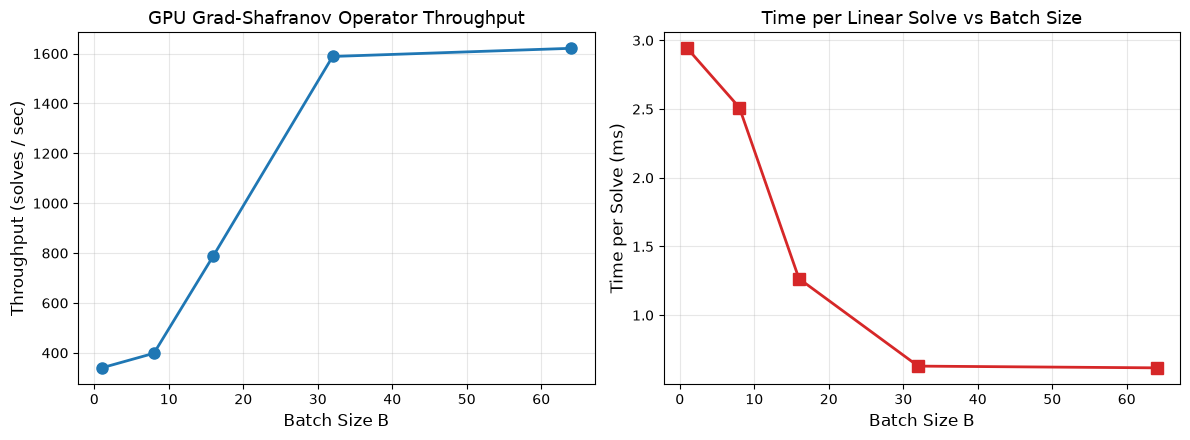

In [6]:
engine = batch_solver.engine
batch_sizes = [1, 8, 16, 32, 64]
throughputs = []
times_per_solve_ms = []

print("Benchmarking JAX GPU Grad-Shafranov linear engine throughput:")
for b_size in batch_sizes:
    dummy_batch_jtor = np.random.randn(b_size, eq.nx, eq.ny)
    # Warmup
    engine.batched_compute_gs_solution(dummy_batch_jtor)[0].block_until_ready()
    
    N_REPS = 10
    t_start = time.perf_counter()
    for _ in range(N_REPS):
        res = engine.batched_compute_gs_solution(dummy_batch_jtor)
        res[0].block_until_ready()
    t_total = (time.perf_counter() - t_start) / N_REPS
    
    tp = b_size / t_total
    ms_per_solve = (t_total / b_size) * 1000.0
    throughputs.append(tp)
    times_per_solve_ms.append(ms_per_solve)
    print(f"  Batch size {b_size:2d}: {tp:7.1f} solves/s ({ms_per_solve:6.3f} ms/solve)")

# Plot scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(batch_sizes, throughputs, marker="o", color="#1f77b4", lw=2, markersize=8)
ax1.set_xlabel("Batch Size B", fontsize=12)
ax1.set_ylabel("Throughput (solves / sec)", fontsize=12)
ax1.set_title("GPU Grad-Shafranov Operator Throughput", fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.plot(batch_sizes, times_per_solve_ms, marker="s", color="#d62728", lw=2, markersize=8)
ax2.set_xlabel("Batch Size B", fontsize=12)
ax2.set_ylabel("Time per Solve (ms)", fontsize=12)
ax2.set_title("Time per Linear Solve vs Batch Size", fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Visualizing the Solved Equilibrium Ensemble
We plot the 2D poloidal flux distribution $\psi(R, Z)$, magnetic axis, and boundary flux surface for all 8 members of the solved batch.


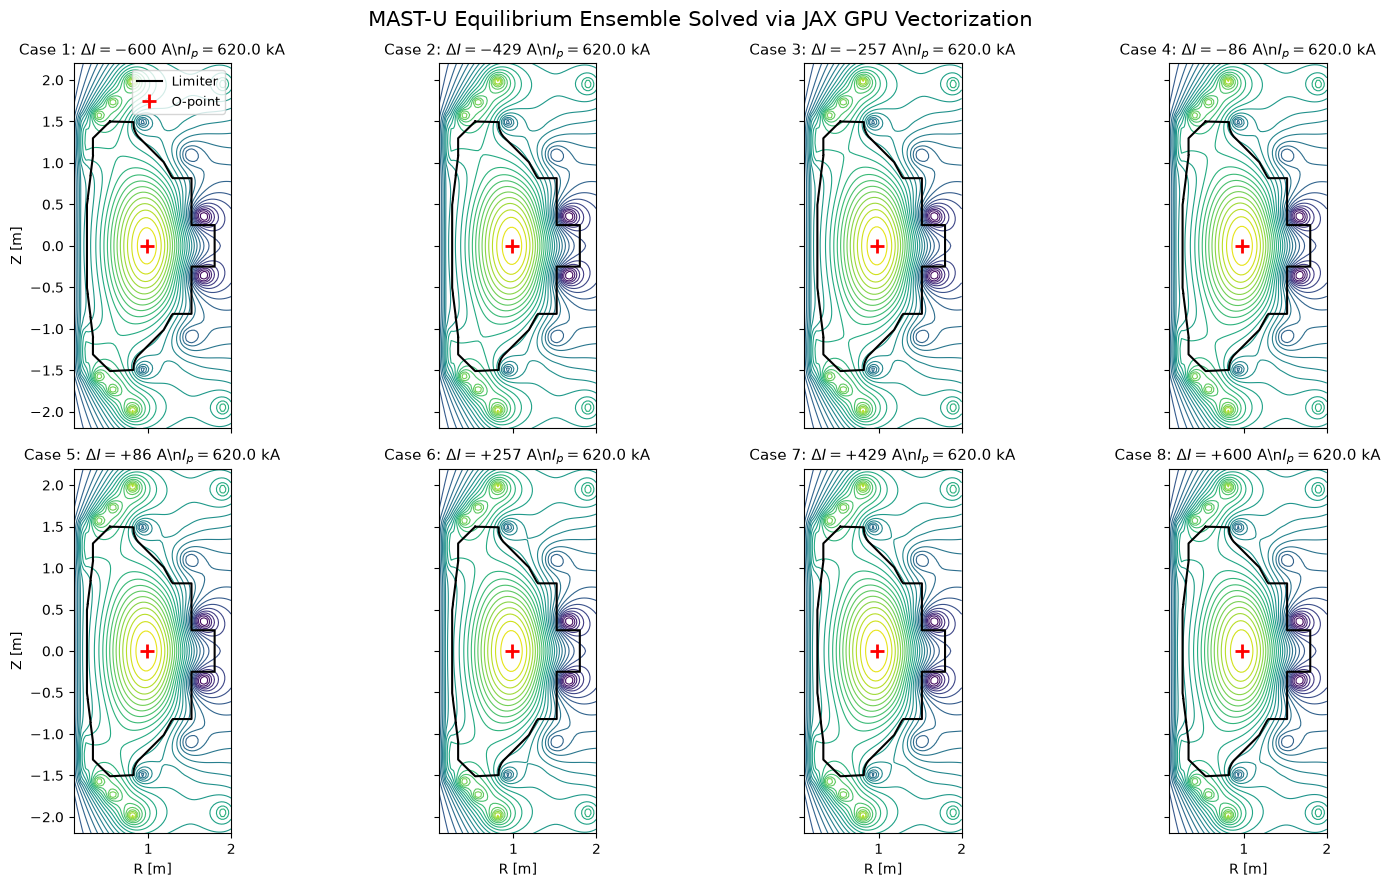

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.ravel()

R_grid = eq.R[:, 0]
Z_grid = eq.Z[0, :]

for b in range(B):
    ax = axes[b]
    psi_total = eq_list[b].plasma_psi + eq_list[b].tokamak_psi
    
    # Contour plot of poloidal flux
    cs = ax.contour(R_grid, Z_grid, psi_total.T, levels=30, cmap="viridis", linewidths=0.8)
    
    # Draw limiter
    lim_R = eq.tokamak.limiter.R
    lim_Z = eq.tokamak.limiter.Z
    ax.plot(lim_R, lim_Z, "k-", lw=1.5, label="Limiter")
    
    # Mark magnetic axis
    if len(eq_list[b].opt) > 0:
        ax.plot(eq_list[b].opt[0, 0], eq_list[b].opt[0, 1], "r+", markersize=10, mew=2, label="O-point")
        
    ax.set_title(rf"Case {b+1}: $\Delta I = {delta_I[b]:+5.0f}$ A\n$I_p = {eq_list[b]._current/1e3:.1f}$ kA", fontsize=11)
    ax.set_aspect("equal")
    if b >= 4:
        ax.set_xlabel("R [m]")
    if b % 4 == 0:
        ax.set_ylabel("Z [m]")

axes[0].legend(loc="upper right", fontsize=9)
plt.suptitle("MAST-U Equilibrium Ensemble Solved via JAX GPU Vectorization", fontsize=15, y=0.98)
plt.tight_layout()
plt.show()
